## Flanking versus breaching

flanking = "lateral scour around the berm end" and breaching = "perpendicular break through the berm" (Nichols et al., 2023).
More flanking on coarser (loamy sand) soils and more breaching on finer (clay loam) soils: ~47% flanked on loamy sand vs ~31% on clay loam; breaches ~17% on clay loam vs ~9% on loamy sand (Nichols et al., 2023, Results 3.1)

 Flanking is more common than breaching overall, and that coarser soils  (loamy sand) have more flanking, while clay loam has more breaches  (their Table 1 / results 3.1). 


Erodibility / cohesion (scourability of the berm end)
- Sandy/loamy sand has low cohesion (low clay), so once water is routed around an end, it can incise a scour pathway quickly → more flanking.
- Clay loam / silt-rich soils are typically more cohesive/structured, so end scour is harder to initiate/maintain → less flanking.

Hydrology (ponding + overtopping vs lateral bypass)
- Finer textures tend to generate more runoff/ponding behind a berm. If water can't easily escape around ends (or the soil resists end scour), the system is pushed toward overtopping → breaching.

 Where breaches occurred on coarser textured soils, the  up and downslope differences in grass cover diminished.



coarser classes (esp. sandy loam, loamy coarse sand) skew toward more flanking,
clay loam shows a higher breach share than sandy loam, and silt loam behaves more like the finer/medium group (higher intactness, lower flanking than sandy loam).


 Almost half (47%) of the berms on the loamy sand soils were fanked in 
comparison with 31% on the ner textured clay loam soils. However,
breaches were more common on the clay loams soils (17% of berms)
in comparison with those on loamy sand soils (9%).

---

## Reference

Nichols, M. H., Duke, S. E., Holifield Collins, C., & Thompson, L. (2023). Legacy earthen berms influence vegetation and hydrologic complexity in the Altar Valley, Arizona. *International Soil and Water Conservation Research*. https://doi.org/10.1016/j.iswcr.2023.01.005


In [28]:
import pandas as pd
import glob
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"seaborn(\..*)?")

# Global display preferences (apply notebook-wide)
from IPython.display import display, HTML
pd.set_option("display.max_columns", 50)


## Query soil data from API

In [29]:
import json
import re
import requests

URL = "https://sdmdataaccess.sc.egov.usda.gov/Tabular/post.rest"


def sda_post(sql: str, timeout=90) -> dict:
    payload = {"query": sql, "format": "JSON"}
    r = requests.post(
        URL,
        data=json.dumps(payload),
        headers={"Content-Type": "application/json"},
        timeout=timeout,
    )
    r.raise_for_status()

    txt = r.text or ""
    if len(txt.strip()) == 0:
        raise RuntimeError(
            "SDA returned an empty response body (timeout/limits). Try again or simplify query.")
    if txt.lstrip().startswith("<"):
        raise RuntimeError(f"SDA returned non-JSON (starts with '<'). First 400 chars:\n{txt[:400]}")
    return r.json()

def sda_to_df(resp: dict) -> pd.DataFrame:
    table_key = next((k for k, v in resp.items() if isinstance(v, list)), None)
    if table_key is None:
        raise RuntimeError(f"Unexpected SDA JSON keys: {list(resp.keys())}")
    return pd.DataFrame(resp[table_key])

def norm_landform(s) -> str:
    if s is None:
        return "unknown"
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s if s else "unknown"

# your one explicit recode
RECODE_EXACT = {"basin floors, fan terraces": "fan terraces"}

def canonical_landform(lf: str) -> str:
    lf = norm_landform(lf)
    return RECODE_EXACT.get(lf, lf)


def classify_landform(lf: str) -> str:
    lf = canonical_landform(lf)

    # Priority 1: stream terraces (always its own class)
    if ("stream terraces" in lf) :
        return "Stream terraces"

    # Priority 2: fans + fan terraces (incl alluvial fans + fan remnants)
    if ("fan terraces" in lf) or ("alluvial fans" in lf) or ("fan remnants" in lf) \
      or ("eroded fan" in lf) or ("fans" in lf) or ("fan piedmonts" in lf):
        return "Fan terraces"

    # Priority 3: valley bottom (basin floors + flood plains + drainageways/swales)
    if ("flood plains" in lf) or ("basin floors" in lf) or ("drainageways" in lf) or \
       ("swales" in lf) or ("plains" in lf):
        return "Flood plains"

    # Priority 4: uplands (hills/mountains/pediments + combos)
    if ("hills" in lf) or ("mountains" in lf) or ("pediments" in lf) or ("ridges" in lf):
        return "Fan terraces"# "Uplands"

    if ("terraces" in lf) :
        return "Stream terraces"    
    
    return  "Unknown"


def print_gee_dict(varname: str, d: dict):
    print(f"\nvar {varname} = ee.Dictionary({{")
    for k in sorted(d.keys(), key=lambda x: int(x) if str(x).isdigit() else str(x)):
        v = str(d[k]).replace("'", "\\'")
        print(f"  '{k}': '{v}',")
    print("});")

# -------------------------
# Curated overrides (optional; keep if you trust these more than SDA)
# -------------------------
MUKEY_to_landform_base = {
    "53807": "stream terraces",
    "53875": "flood plains",
    "53793": "fan terraces",
    "53738": "fan terraces",
    "53806": "flood plains",
    "53895": "fan terraces",
    "53886": "fan terraces, hills",
    "53799": "stream terraces",
    "53759": "flood plains",
}

mukeys_extra = [
    "1416070","1421630","1421631","1423101","1425287","1425309","1425386","1425394",
    "1425688", "1426107","1426108","1426109", "1427770","1427772","1427773","1427775", 
    "1427776","1427809","1427812","1427814","1427815","1427817","54393","54430",
    "53533","53539","53540","53546","53550","53557","53562","53563","53569",
    "53739","53741","53744","53750","53754","53756","53757","53767","53768",
    "53781","53783","53786","53788","53795","801772","801773","801777",
    "53808","53810","53812","53816","53817","53820","53822","53823","53824","53826",
    "53830","53832","53834","53838","53839","53840","53827","53863","54658","54594",
    "53844","53845","53846","53849","53851","53853","53855","53857","53859","53861",
    "53864","53865","53867","53868","53869","53876","53879","53881","53883","53885",
    "53891","53892","53897","53898","53899","53901","53902","53903","53907","53910",
    "54340","54341","54342","54343","54344","54345","54347","54365","53887","54364",
    "54354","54355","54356","54357","54358","54359","54360","54361","54362","54363",
    "54367","54370","54372","54374","54375","54376","54377","54378","54379","54380",
    "54382","54383","54384","54385","54386","54387","54389","54390","54391","54392",
    "54397","54398","54399","54400","54401","54402","54426","54427","54428","54429",
    "54404","54405","54406","54407","54408","54409","54410","54412","54413","54395",
    "54415","54416","54417","54418","54419","54420","54421","54423","54424","54654",
    "54538","54544","54546","54553","54555","54557","54561","54567","54582","54585",
    "54601","54609","54612","54616","54626","54628","54632","54635","54639","54645",
    "54661","54672",

]

mukeys = sorted(set(list(MUKEY_to_landform_base.keys()) + mukeys_extra), key=int)
in_list = ",".join(f"'{m}'" for m in mukeys)



def fetch_landforms_batch(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)
    sql = f"""
    WITH dom AS (
      SELECT
        c.mukey, c.cokey, c.compname, c.comppct_r,
        ROW_NUMBER() OVER (PARTITION BY c.mukey ORDER BY c.comppct_r DESC) AS rn
      FROM component c
      WHERE c.mukey IN ({in_list})
    )
    SELECT
      m.mukey,
      l.areasymbol,
      m.musym,
      m.muname,
      d.compname,
      d.comppct_r,
      cg.geomfname AS landform
    FROM mapunit m
    JOIN legend l ON l.lkey = m.lkey
    JOIN dom d ON d.mukey = m.mukey AND d.rn = 1
    LEFT JOIN cogeomordesc cg
      ON cg.cokey = d.cokey
     AND cg.geomftname = 'Landform'
     AND cg.rvindicator = 'yes'
    ORDER BY m.mukey;
    """
    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "areasymbol",
        2: "musym",
        3: "muname",
        4: "compname",
        5: "comppct_r",
        6: "landform",

    })
    dfb["mukey"] = dfb["mukey"].astype(str)
    dfb["landform"] = dfb["landform"].apply(norm_landform)
    return dfb

BATCH_SIZE = 150
df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_landforms_batch(mukeys[i:i + BATCH_SIZE]))

df = pd.concat(df_parts, ignore_index=True)

# collapse multiple landforms per MUKEY (if any)
mukey_landforms_sda = (
    df.dropna(subset=["landform"])
      .groupby("mukey")["landform"]
      .apply(lambda s: ", ".join(sorted(set(s.astype(str)))))
      .to_dict()
 )

# raw landforms (canonicalized) for all requested mukeys
MUKEY_to_landform_raw = {mk: canonical_landform(mukey_landforms_sda.get(mk, "unknown")) for mk in mukeys}
MUKEY_to_landform_raw.update({k: canonical_landform(v) for k, v in MUKEY_to_landform_base.items()})  # curated override

# THIS is the simplified MUKEY_to_landform you want
MUKEY_to_landform = {mk: classify_landform(lf) for mk, lf in MUKEY_to_landform_raw.items()}

print(pd.Series(MUKEY_to_landform).value_counts())


Fan terraces       145
Flood plains        35
Stream terraces     17
Unknown              4
Name: count, dtype: int64


In [30]:
def fetch_landforms_texture_batch(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)


    sql = f"""
    WITH dom AS (
      SELECT
        c.mukey, c.cokey, c.compname, c.comppct_r,
        ROW_NUMBER() OVER (PARTITION BY c.mukey ORDER BY c.comppct_r DESC) AS rn
      FROM component c
      WHERE c.mukey IN ({in_list})
    ),
    surf_hz AS (
      -- pick the topmost horizon for the dominant component
      SELECT
        ch.cokey, ch.chkey, ch.hzdept_r, ch.hzdepb_r,
        ch.sandtotal_r, ch.silttotal_r, ch.claytotal_r,
        ROW_NUMBER() OVER (
          PARTITION BY ch.cokey
          ORDER BY
            CASE WHEN ch.hzdept_r = 0 THEN 0 ELSE 1 END,
            ch.hzdept_r
        ) AS rn
      FROM chorizon ch
      JOIN dom d ON d.cokey = ch.cokey AND d.rn = 1
      WHERE ch.hzdept_r IS NOT NULL
        AND ch.hzdepb_r IS NOT NULL
        AND ch.hzdepb_r > 0
    ),
    tex AS (
      -- representative texture class for that surface horizon
      SELECT
        t0.chkey,
        t0.texcl
      FROM (
        SELECT
          chtg.chkey,
          ct.texcl,
          ROW_NUMBER() OVER (
            PARTITION BY chtg.chkey
            ORDER BY
              CASE WHEN chtg.rvindicator = 'yes' THEN 0 ELSE 1 END,
              ct.texcl
          ) AS rn
        FROM chtexturegrp chtg
        JOIN chtexture ct ON ct.chtgkey = chtg.chtgkey
      ) t0
      WHERE t0.rn = 1
    )
    SELECT
      m.mukey,
      l.areasymbol,
      m.musym,
      m.muname,
      d.compname,
      d.comppct_r,
      cg.geomfname AS landform,
      hz.sandtotal_r,
      hz.silttotal_r,
      hz.claytotal_r,
      tx.texcl
    FROM mapunit m
    JOIN legend l ON l.lkey = m.lkey
    JOIN dom d ON d.mukey = m.mukey AND d.rn = 1
    LEFT JOIN cogeomordesc cg
      ON cg.cokey = d.cokey
     AND cg.geomftname = 'Landform'
     AND cg.rvindicator = 'yes'
    LEFT JOIN surf_hz hz
      ON hz.cokey = d.cokey AND hz.rn = 1
    LEFT JOIN tex tx
      ON tx.chkey = hz.chkey
    ORDER BY m.mukey;
    """

    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "areasymbol",
        2: "musym",
        3: "muname",
        4: "compname",
        5: "comppct_r",
        6: "landform",
        7: "sandtotal_r",
        8: "silttotal_r",
        9: "claytotal_r",
        10: "texcl",
    })

    dfb["mukey"] = dfb["mukey"].astype(str)
    dfb["landform"] = dfb["landform"].apply(norm_landform)
    return dfb

BATCH_SIZE = 150
df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_landforms_texture_batch(mukeys[i:i + BATCH_SIZE]))
df = pd.concat(df_parts, ignore_index=True)

df['sandtotal_r'] = df['sandtotal_r'].astype(float)
df['claytotal_r'] = df['claytotal_r'].astype(float)
df['silttotal_r'] = df['silttotal_r'].astype(float)

MUKEY_to_texcl = df.set_index("mukey")["texcl"].fillna("unknown").to_dict()

MUKEY_to_clay = df.set_index("mukey")["claytotal_r"].to_dict()  # numeric %, may be NaN
MUKEY_to_sand = df.set_index("mukey")["sandtotal_r"].to_dict()
MUKEY_to_silt = df.set_index("mukey")["silttotal_r"].to_dict()

In [31]:
df["muname_base"] = (
    df["muname"]
      .astype(str)
      .str.split(",", n=1).str[0]
      .str.strip()
)
df["muname_base"].value_counts().head(30)


slope_re = re.compile(r"(\d+)\s*(?:to|-)\s*(\d+)\s*percent", re.I)

def parse_slope_range(s):
    m = slope_re.search(str(s))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))

df[["slope_lo", "slope_hi"]] = df["muname"].apply(parse_slope_range).apply(pd.Series)

In [32]:
# 1) clean the name (drop slope text after comma; drop trailing MLRA notes)
df = df.copy()
df["muname_core"] = (
    df["muname"].astype(str).str.lower()
      .str.split(",").str[0]
      .str.replace(r"\s+mlra.*$", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# 2) texture terms (order matters: longest first)
texture_terms = [
    "very fine sandy loam",
    "fine sandy loam",
    "loamy coarse sand",
    "loamy sand",
    "sandy clay loam",
    "silty clay loam",
    "clay loam",
    "silt loam",
    "sandy loam",
    "sandy clay",
    "silty clay",
    "clay",
    "silt",
    "loam",
    "sand",
]
tex_re = r"\b(" + "|".join(map(re.escape, texture_terms)) + r")\b"

# 3) optional coarse-fragment modifiers right before the texture term
mods_re = r"(?P<mods>(?:\b(?:extremely|very)?\s*(?:gravelly|cobbly|stony|channery|shaly)\b\s*)+)?"

pat = mods_re + r"(?P<texture>" + tex_re + r")"

ex = df["muname_core"].str.extract(pat)

df["texture_class"] = ex["texture"].str.strip().str.replace(r"\s+", " ", regex=True).str.title()


## Load CSVs in data folder (GEE exports)

In [33]:
# --- 1) Load and combine CSV files --------------------------------------------------
# Find all CSVs matching the pattern (e.g., AOI01_bermdata_20250205.csv) in the folder.

file_paths = sorted(glob.glob('../data/berm_exports/AOI*_bermdata_*0130.csv'))

# Read each CSV into a DataFrame.
df_list = [pd.read_csv(fp) for fp in file_paths]

# Concatenate all AOI data into a single DataFrame (resetting the row index).
data = pd.concat(df_list, ignore_index=True)


# --- 2) MUKEY mapping dictionaries --------------------------------------------------
# These dicts translate MUKEY (soil map unit keys) to human-readable attributes.
# Note: MUKEYs are strings; keep keys as strings to avoid mismatches later.

MUKEY_to_mapunitname = {
    '53807': 'Glendale silt loam, 0 to 3 percent slopes',
    '53875': 'Riveroad and Comoro soils, 0 to 2 percent slopes',
    '53793': 'Diaspar sandy loam, 1 to 5 percent slopes',
    '53738': 'Altar-Sasabe complex, 1 to 8 percent slopes',
    '53806': 'Anthony fine sandy loam, 0 to 3 percent slopes',
    '53895': 'Bucklebar-Sahuarita complex, 0 to 3 percent slopes',
    '53886': 'Sasabe-Caralampi complex, 1 to 15 percent slopes',
    '53799': 'Glendale-Bucklebar complex, 0 to 3 percent slopes',
    '53759': 'Comoro sandy loam, 0 to 2 percent slopes'
}

MUKEY_to_slopeclass = {
    '53807': 'low', '53875': 'low', '53793': 'high', '53738': 'high',
    '53806': 'low', '53895': 'low', '53886': 'high', '53799': 'low', 
    '53759': 'low'
}

MUKEY_to_parentmaterial = {
    '53807': 'Mixed alluvium',
    '53875': 'Moderately fine textured alluvium, Moderately coarse textured alluvium',
    '53793': 'Alluvium derived from granite and/or alluvium derived from schist',
    '53738': 'Alluvium derived from schist and/or alluvium derived from granite, Mixed alluvium',
    '53806': 'Mixed alluvium', 
    '53895': 'Mixed alluvium', 
    '53886': 'Mixed alluvium',
    '53799': 'Mixed alluvium', 
    '53759': 'Mixed alluvium'
}


MUKEY_to_typicalprofile = {
    '53807': 'A-C', '53875': 'A-C, A-C1-C2-C3', '53793': 'A-Bt-2Bt-3BCt',
    '53738': 'A-Bw-BC-C, A-Bt1-Bt2-Bt3-2Btk', '53806':  'A-AC-C-Ck-C',
    '53895': 'A/Bt-Bt-Btk, A-Bk-2Btkb1-2Btkb2', '53886': 'A-Bt1-Bt2-Bt3-Btk, A-Bt1-Bt2-2C',
    '53799': 'A-C, A/Bt-Bt-Btk', '53759': 'A1-A2-C1-C2'
}



In [34]:
# Rebuild MUKEY -> typical horizon sequence(s) from Soil Data Access
mukeys = sorted(data["MUKEY"].dropna().astype(str).unique())
BATCH_SIZE = 150

def fetch_horizons_for_mukeys(batch_mukeys):
    in_list = ",".join(f"'{m}'" for m in batch_mukeys)
    sql = f"""
    SELECT
      c.mukey,
      c.cokey,
      c.compname,
      c.comppct_r,
      c.majcompflag,
      h.hzname,
      h.hzdept_r
    FROM component c
    JOIN chorizon h ON h.cokey = c.cokey
    WHERE c.mukey IN ({in_list})
      AND h.hzname IS NOT NULL
    ORDER BY c.mukey, c.comppct_r DESC, c.cokey, h.hzdept_r;
    """
    resp = sda_post(sql)
    dfb = sda_to_df(resp).rename(columns={
        0: "mukey",
        1: "cokey",
        2: "compname",
        3: "comppct_r",
        4: "majcompflag",
        5: "hzname",
        6: "hzdept_r",
    })
    dfb["mukey"] = dfb["mukey"].astype(str)
    return dfb

df_parts = []
for i in range(0, len(mukeys), BATCH_SIZE):
    df_parts.append(fetch_horizons_for_mukeys(mukeys[i:i+BATCH_SIZE]))

hz = pd.concat(df_parts, ignore_index=True)

# Choose which components to include:
# Option A: only major components (often matches "multiple profiles per MUKEY")
hz_use = hz[hz["majcompflag"].str.lower().eq("yes")].copy()

# If that yields empty for some MUKEYs, fall back to dominant component:
if hz_use.empty:
    hz_use = hz.copy()

hz_use = hz_use.sort_values(["mukey", "comppct_r", "cokey", "hzdept_r"],
                            ascending=[True, False, True, True])

# Horizon sequence per component
comp_profiles = (
    hz_use.groupby(["mukey", "cokey"], as_index=False)
          .agg(profile=("hzname", lambda s: "-".join(s.astype(str))))
)

# Join unique component profiles per MUKEY
MUKEY_to_typicalprofile_auto = (
    comp_profiles.groupby("mukey")["profile"]
                 .apply(lambda s: ", ".join(pd.unique(s)))
                 .to_dict()
)

MUKEY_to_typicalprofile = MUKEY_to_typicalprofile_auto

# --- 3) Standardize MUKEY and apply mappings ---------------------------------------
# Ensure MUKEY is string so dictionary lookups work even if the source was numeric.
data['MUKEY'] = data['MUKEY'].astype(str)
# Robust MUKEY normalization: keeps missing as <NA> and removes .0 issues

data['MapUnitName'] = data['MUKEY'].map(MUKEY_to_mapunitname)
data['SlopeClass'] = data['MUKEY'].map(MUKEY_to_slopeclass)
data['Landform'] = data['MUKEY'].map(MUKEY_to_landform)
data['ParentMaterial'] = data['MUKEY'].map(MUKEY_to_parentmaterial)
data['TypicalProfile'] = data['MUKEY'].map(MUKEY_to_typicalprofile)
data['Texture'] = data['MUKEY'].map(MUKEY_to_texcl)

data['claytotal_r'] = data['MUKEY'].map(MUKEY_to_clay)
data['sandtotal_r'] = data['MUKEY'].map(MUKEY_to_sand)
data['silttotal_r'] = data['MUKEY'].map(MUKEY_to_silt)

# Harmonize landform label 
data['Landform'] = data['Landform'].replace({"Fan terraces, hills": "Fan terraces"})

# Check for unmatched MUKEYs 
# Inspect MUKEYs that did not find a match in the dictionaries—useful QA check.
unmatched_keys = data[data['MapUnitName'].isna()]['MUKEY'].unique()
print(f"Unmatched MUKEYs: {unmatched_keys}")

# Landform is from MUKEYS

Unmatched MUKEYs: ['53844' '53897' '53817' '53855' '53899' '53744' '53820' '53849' '53757'
 '53902' '53907' '53865' '53822' '53826' '53846' '53783' '53901' '53788'
 '53812' '53879' '53827' '1423101' '53756' '53864']


In [35]:
# --- Classify berm condition -----------------------------------------------------
# Fill missing failure types as "Intact" and collapse to a binary condition:
# "Intact" vs "Degraded" (anything not exactly "Intact" is considered degraded).
data['Fail_Type'] = data['Fail_Type'].fillna("Intact")
data['Condition'] = data['Fail_Type'].apply(lambda x: 'Intact' if x == 'Intact' else 'Degraded')
data = data.loc[data.query("Fail_Type != 'Breach and Flank'").index]

# --- 5) Group and summarize ---------------------------------------------------------
# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Condition']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)


# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Fail_Type']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)

# Convert counts to within-landform proportions (rows sum to 1), rounded to 2 decimals.
summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
print("\nProportion of Berm Conditions by Landform:\n")
print(summary_proportions)

data['savi_background'] = data['savi_background'].replace(0, np.nan)

data['effect'] = (data['saviU_60'] - data['saviD_60'])  / data['savi_background']
data['effect_percent'] = data['effect'] * 100


data['Landform'] = data['Landform'].replace({ "Fan terraces, hills": "Fan terraces"})


Berm Integrity Counts by Landform:

Condition        Degraded  Intact
Landform                         
Fan terraces          123     153
Flood plains          144     215
Stream terraces        50      90

Berm Integrity Counts by Landform:

Fail_Type        Breach  Flank  Intact
Landform                              
Fan terraces         31     92     153
Flood plains         64     80     215
Stream terraces      19     31      90

Proportion of Berm Conditions by Landform:

Fail_Type        Breach  Flank  Intact
Landform                              
Fan terraces       0.11   0.33    0.55
Flood plains       0.18   0.22    0.60
Stream terraces    0.14   0.22    0.64


In [36]:
# Define berm length category
data = data.dropna(subset=['Shape_Leng', 'Fail_Type'])

data['Berm_Length_Class'] = data['Shape_Leng'].apply(
    lambda x: 'Short (≤ 50 m)' if x <= 50 else 'Long (> 50 m)'
)

# Bin slope
data['Slope_Class'] = data['slope_100'].apply(
    lambda x: "Shallow (≤ 2%)" if x <= 2 else "Steep (> 2%)"
)

data['Soil_Development'] = data['TypicalProfile'].astype(str).apply(
    lambda x: 'B horizon' if 'B' in x else 'No B horizon'
)

data['effective'] = False
data.loc[data['effect_percent'] > 7, 'effective'] =  True
data.loc[data['effect_percent'] < 7, 'effective'] = False

data['Effective'] = ''
data.loc[data['effect_percent'] > 7, 'Effective'] =  'Effective'
data.loc[data['effect_percent'] < 7, 'Effective']=  'Ineffective'

data['High_Clay'] = data['claytotal_r'] > data['claytotal_r'].median()
data['Intact'] = data['Condition'] == 'Intact'



In [37]:
# landform : from my dataset
data['proximity'] = data['landform'].replace({
    0 : 'Upland',
    1 : 'Flood plain'    
})


In [38]:
# data.groupby("Texture")['effective'].mean(),\
data.query("Fail_Type =='Breach'").groupby("Texture")['effective'].mean()
# Where breaches occurred on coarser textured soils, the  up and downslope differences in grass cover diminished.



Texture
Clay loam          0.471698
Fine sandy loam    0.625000
Loam               1.000000
Loamy sand         0.500000
Sandy clay loam    0.000000
Sandy loam         0.428571
Silt loam          0.578947
Name: effective, dtype: float64

In [39]:
# Keep textures with >=10 samples in each Intact category, then summarize
sub = data.dropna(subset=["Texture", "Intact", "effective"]).copy()

counts = sub.groupby(["Texture", "Intact"]).size().unstack(fill_value=0)
valid_textures = counts[(counts.min(axis=1) >= 10)].index

texture_order = ["Clay loam",  "Silt loam",  "Loam", "Fine sandy loam", "Sandy loam"]

out = (
    sub[sub["Texture"].isin(valid_textures)]
      .groupby(["Texture", "Intact"])["effective"]
      .agg(mean="mean", count="size")
      .reset_index()
      .assign(Texture=lambda d: pd.Categorical(d["Texture"], categories=texture_order, ordered=True))
      .sort_values(["Texture", "Intact"])
      .reset_index(drop=True)
)

# intact berms - more effective than degraded berms on coarser soils (sandy loam, fine sandy loam)

In [40]:
# For each texture: test whether effectiveness differs between Intact vs Degraded berms
sub = data.dropna(subset=["Texture", "Intact", "effective"]).copy()

# Optional guard to avoid testing very sparse categories
MIN_N_PER_CATEGORY = 10

# Mean/count summary by texture and intact status
summary = (
    sub.groupby(["Texture", "Intact"])["effective"]
       .agg(mean="mean", count="size")
       .reset_index()
       .assign(Group=lambda d: d["Intact"].map({False: "Degraded", True: "Intact"}))
       .drop(columns="Intact")
       .sort_values(["Texture", "Group"])
       .reset_index(drop=True)
)

rows = []
for texture, g in sub.groupby("Texture"):
    ct = pd.crosstab(g["Intact"], g["effective"]).reindex(
        index=[False, True], columns=[False, True], fill_value=0
    )

    n_degraded = int(ct.loc[False].sum())
    n_intact = int(ct.loc[True].sum())
    p_degraded = (ct.loc[False, True] / n_degraded) if n_degraded > 0 else np.nan
    p_intact = (ct.loc[True, True] / n_intact) if n_intact > 0 else np.nan

    if min(n_degraded, n_intact) >= MIN_N_PER_CATEGORY:
        table = [
            [ct.loc[False, False], ct.loc[False, True]],
            [ct.loc[True,  False], ct.loc[True,  True]],
        ]
        odds_ratio, p_value = fisher_exact(table, alternative="two-sided")
        tested = True
    else:
        odds_ratio, p_value = np.nan, np.nan
        tested = False

    rows.append({
        "Texture": texture,
        "n_degraded": n_degraded,
        "n_intact": n_intact,
       "p_effective_degraded": p_degraded,
       "p_effective_intact": p_intact,
       # "odds_ratio": odds_ratio,
        "p_value": p_value,
        "significant_0p05": (p_value < 0.05) if pd.notna(p_value) else False
    })

results = (
    pd.DataFrame(rows)
      .sort_values([ "p_value", "Texture"], ascending=[ True, True])
      .reset_index(drop=True)
)

display(summary)
display(results)
# on corase soils, intact berms tend to be more effective.
# on finer soils, intact berms tend to be less effective, but the difference is not significant.

,Texture,mean,count,Group
0,Clay loam,0.416667,108,Degraded
1,Clay loam,0.377143,175,Intact
2,Fine sandy loam,0.571429,21,Degraded
3,Fine sandy loam,0.363636,33,Intact
4,Loam,0.571429,14,Degraded
5,Loam,0.289474,38,Intact
6,Loamy coarse sand,0.400000,5,Degraded
7,Loamy coarse sand,0.250000,4,Intact
8,Loamy sand,0.200000,5,Degraded
9,Loamy sand,0.333333,3,Intact


,Texture,n_degraded,n_intact,p_effective_degraded,p_effective_intact,p_value,significant_0p05
0,Sandy loam,113,97,0.530973,0.680412,0.034068,True
1,Loam,14,38,0.571429,0.289474,0.103020,False
2,Fine sandy loam,21,33,0.571429,0.363636,0.166631,False
3,Clay loam,108,175,0.416667,0.377143,0.532521,False
4,Silt loam,49,88,0.510204,0.556818,0.720822,False
5,Loamy coarse sand,5,4,0.400000,0.250000,NaN,False
6,Loamy sand,5,3,0.200000,0.333333,NaN,False
7,Sandy clay loam,2,20,0.500000,0.400000,NaN,False


In [41]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
)

# Align Effective column values with canonical labels from constants.py
data['Effective'] = data['Effective'].map({
    'Effective':   LBL_EFFECTIVE,
    'Ineffective': LBL_INEFFECTIVE,
})


In [42]:

sub = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()
sub = sub.dropna(subset=["Fail_Type", "Texture"])

# 1) Counts: Texture × Fail_Type
ct = pd.crosstab(sub["Texture"], sub["Fail_Type"])
ct_t = ct.copy()
ct_t['Total'] = np.sum(ct_t, axis=1)

# 2) Within-texture proportions (rows sum to 1)
ct_row = ct.div(ct.sum(axis=1), axis=0)
display((ct_row * 100).round(1))



Fail_Type,Breach,Flank,Intact
Texture,,,
Clay loam,20.7,19.9,59.3
Fine sandy loam,15.4,33.3,51.3
Loam,8.6,31.4,60.0
Loamy coarse sand,0.0,55.6,44.4
Loamy sand,28.6,28.6,42.9
Sandy clay loam,0.0,0.0,100.0
Sandy loam,13.2,41.5,45.4
Silt loam,12.0,27.0,61.0


In [43]:
# merge shapefile attrs into existing pandas df `data` on rounded lat/lon
# keep lower-case; do not bring over shapefile columns that duplicate names in `data`

import geopandas as gpd
import os
# --- config ---
shp_path  = "../data/Berm_Directionality/Berm_Directionality.shp"
out_csv   = "../data/merged.csv"
round_ndp = 6

# --- helpers ---
def _normalize_cols(df):
    df = df.copy()
    df.columns = [c.strip().replace(" ", "_") for c in df.columns]
    return df

def _find_lat_lon(cols):
    lc = {c.lower(): c for c in cols}
    lat_candidates = ["lat","latitude","y","lat_dd"]
    lon_candidates = ["lon","long","longitude","x","lon_dd"]
    lat = next((lc[c] for c in lat_candidates if c in lc), None)
    lon = next((lc[c] for c in lon_candidates if c in lc), None)
    return lat, lon

def _ll_key(df, lat_col, lon_col, ndp=6):
    lat = pd.to_numeric(df[lat_col], errors="coerce").round(ndp)
    lon = pd.to_numeric(df[lon_col], errors="coerce").round(ndp)
    return lat.astype("string") + "_" + lon.astype("string")

# --- require an existing `data` dataframe ---
if "data" not in globals():
    raise NameError("expected a pandas dataframe named `data` in memory")

data = _normalize_cols(data)
data_lat, data_lon = _find_lat_lon(data.columns)
if not data_lat or not data_lon:
    raise KeyError(f"couldn't find lat/lon in `data`; columns: {list(data.columns)}")

# read shapefile, normalize cols
gdf = gpd.read_file(shp_path)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
elif gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)
gdf = _normalize_cols(gdf)

shp_lat, shp_lon = _find_lat_lon(gdf.columns)
if not shp_lat or not shp_lon:
    raise KeyError(f"couldn't find lat/lon in shapefile; columns: {list(gdf.columns)}")

# build merge keys
left  = data.copy()
right = gdf.drop(columns=["geometry"], errors="ignore").copy()

left["__ll_key__"]  = _ll_key(left,  data_lat, data_lon, ndp=round_ndp)
right["__ll_key__"] = _ll_key(right, shp_lat,  shp_lon,  ndp=round_ndp)

# keep only NON-OVERLAPPING shapefile columns (plus the join key)
cols_to_add = ["__ll_key__"] + [c for c in right.columns if c not in left.columns and c != "__ll_key__"]
right = right[cols_to_add]

# merge (no suffixes needed because we've removed duplicates by name)
merged = left.merge(right, on="__ll_key__", how="left").drop(columns="__ll_key__")

# save
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
merged.to_csv(out_csv, index=False)
print(f"done. merged rows = {len(merged):,} -> {out_csv}")


done. merged rows = 775 -> ../data/merged.csv


In [44]:
from plotting import remove_legend_titles
from registry import (
    update_figure_registry,
    register_paper1_figure,
    register_paper2_figure,
)
from analysis import (
    analyze_outcome,
    rank_predictors,
    fit_rf_binary,
    PRETTY_LABELS,
)


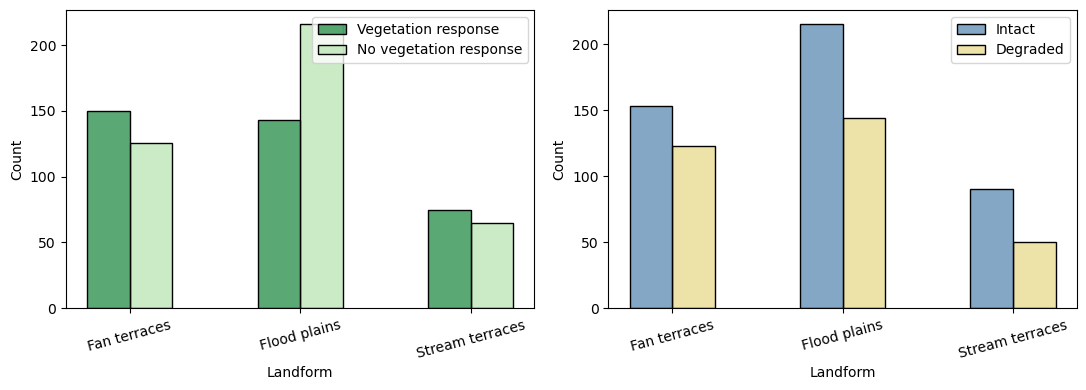

In [45]:
plot_df = data.copy()

plot_df["Intact"] = pd.Categorical(
    np.where(plot_df["Intact"].astype(bool), "Intact", "Degraded"),
    categories=["Intact", "Degraded"], ordered=True
)

palette_eff = eff_colors
palette_int = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stability
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Effective",
    multiple="dodge", shrink=0.5, stat="count",
    palette=palette_eff, hue_order=eff_order,
    ax=axes[0], legend=True
)

# Intactness
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Intact",
    hue_order=["Intact", "Degraded"], palette=palette_int,
    multiple="dodge", shrink=0.5, stat="count",
    ax=axes[1], legend=True
)

# Title/position legends the seaborn way (no manual ax.legend() call)
try:
    sns.move_legend(axes[0], "upper right", title="", frameon=True)
    sns.move_legend(axes[1], "upper right", title="", frameon=True)
except Exception:
    # Fallback for older seaborn: retitle existing legends if present
    if axes[0].legend_ is not None: axes[0].legend_.set_title("Stability")
    if axes[1].legend_ is not None: axes[1].legend_.set_title("Intactness")

for ax in axes:
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
# agregating over 6 years;


## Breaches and flanks separately

In [46]:
from scipy.stats import fisher_exact

thr = 60

df = data.query("Shape_Leng != @thr").copy()
df["len_bin"] = np.where(df["Shape_Leng"] > thr, f"Long (>{thr} m)", f"Short (<{thr} m)")
df["failed"] = df["Fail_Type"].ne("Intact")

long_lbl = f"Long (>{thr} m)"
short_lbl = f"Short (<{thr} m)"

n_long  = len(df[df["len_bin"] == long_lbl])
n_short = len(df[df["len_bin"] == short_lbl])

def _fisher_one_sided(c_l, n_l, c_s, n_s):
    """One-sided Fisher's exact in the direction of the observed difference."""
    table = [[c_l, n_l - c_l], [c_s, n_s - c_s]]
    p_l, p_s = c_l / n_l, c_s / n_s
    direction = "greater" if p_l >= p_s else "less"
    _, p = fisher_exact(table, alternative=direction)
    return p, direction

def _sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

rows = {}
for metric, pos_mask_fn in [
    ("Intact",       lambda d: d["Fail_Type"] == "Intact"),
    ("Any failure",  lambda d: d["failed"]),
    ("Breach",       lambda d: d["Fail_Type"] == "Breach"),
    ("Flank",        lambda d: d["Fail_Type"] == "Flank"),
    (LBL_EFFECTIVE,  lambda d: d["Effective"] == LBL_EFFECTIVE),
]:
    mask = pos_mask_fn(df)
    c_l = mask[df["len_bin"] == long_lbl].sum()
    c_s = mask[df["len_bin"] == short_lbl].sum()
    p_val, direction = _fisher_one_sided(c_l, n_long, c_s, n_short)
    p_l, p_s = c_l / n_long, c_s / n_short
    rows[metric] = {long_lbl: p_l, short_lbl: p_s,
                    "Δ": round(p_l - p_s, 3),
                    "direction": f"Long {'>' if p_l >= p_s else '<'} Short",
                    "p-value (1-sided)": p_val,
                    "sig": _sig_stars(p_val)}

# Conditional metrics (among failed only)
df_f = df[df["failed"]]
n_lf = (df_f["len_bin"] == long_lbl).sum()
n_sf = (df_f["len_bin"] == short_lbl).sum()
for metric, ft in [("Breach | failed", "Breach"), ("Flank | failed", "Flank")]:
    c_l = ((df_f["Fail_Type"] == ft) & (df_f["len_bin"] == long_lbl)).sum()
    c_s = ((df_f["Fail_Type"] == ft) & (df_f["len_bin"] == short_lbl)).sum()
    p_val, direction = _fisher_one_sided(c_l, n_lf, c_s, n_sf)
    p_l, p_s = c_l / n_lf, c_s / n_sf
    rows[metric] = {long_lbl: p_l, short_lbl: p_s,
                    "Δ": round(p_l - p_s, 3),
                    "direction": f"Long {'>' if p_l >= p_s else '<'} Short",
                    "p-value (1-sided)": p_val,
                    "sig": _sig_stars(p_val)}

len_metrics = pd.DataFrame(rows).T
len_metrics[[long_lbl, short_lbl]] = len_metrics[[long_lbl, short_lbl]].astype(float)

display(len_metrics.assign(
    **{long_lbl:  (len_metrics[long_lbl]  * 100).round(1),
       short_lbl: (len_metrics[short_lbl] * 100).round(1),
       "Δ":       len_metrics["Δ"].astype(float).round(3),
       "p-value (1-sided)": len_metrics["p-value (1-sided)"].apply(lambda x: f"{x:.3g}")}
)[[long_lbl, short_lbl, "Δ", "direction", "p-value (1-sided)", "sig"]])

,Long (>60 m),Short (<60 m),Δ,direction,p-value (1-sided),sig
Intact,47.1,70.4,-0.234,Long < Short,2.63e-11,***
Any failure,52.9,29.6,0.234,Long > Short,2.63e-11,***
Breach,21.8,8.0,0.138,Long > Short,3.78e-08,***
Flank,31.1,21.6,0.096,Long > Short,0.00161,**
Vegetation response,48.7,46.4,0.023,Long > Short,0.284,ns
Breach | failed,41.2,27.1,0.141,Long > Short,0.00765,**
Flank | failed,58.8,72.9,-0.141,Long < Short,0.00765,**


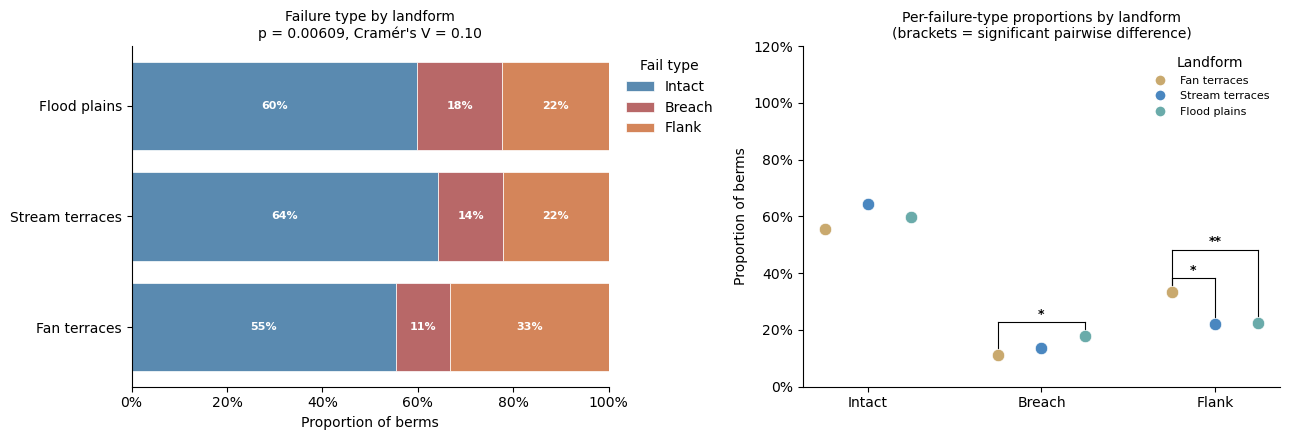

In [47]:

# Failure type breakdown by landform
# Stacked bar: proportion of Intact / Breach / Flank per landform
# + per-failure-type chi-squared tests across landforms

from scipy.stats import chi2_contingency, fisher_exact
from itertools import combinations
from matplotlib.lines import Line2D

fail_types = ["Intact", "Breach", "Flank"]
fail_colors = {"Intact": INTACT_COL, "Breach": BREACH_COL, "Flank": FLANK_COL}

# Colour palette per landform – falls back to grey for any unexpected values
lf_palette = sns.color_palette("tab10", n_colors=10)  # kept for reference

# Proportions: rows = landform, cols = Fail_Type
ct_fail = pd.crosstab(data["Landform"], data["Fail_Type"])
ct_fail = ct_fail.reindex(columns=fail_types, fill_value=0)
props_fail = ct_fail.div(ct_fail.sum(axis=1), axis=0)

# Use consistent landform order
landform_order_ft = ["Fan terraces", "Stream terraces", "Flood plains"]
props_fail = props_fail.loc[landform_order_ft]
lf_colors = {lf: LF_COLORS.get(lf, "#aaaaaa") for lf in landform_order_ft}

# --- Chi-squared test: overall association between Landform & Fail_Type ---
chi2_val, p_ft, dof_ft, _ = chi2_contingency(ct_fail.loc[landform_order_ft])
n_ft = ct_fail.values.sum()
V_ft = np.sqrt(chi2_val / (n_ft * (min(ct_fail.shape) - 1)))
p_str_ft = f"p = {p_ft:.3g}" if p_ft >= 0.001 else "p < 0.001"

def _sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: stacked bar chart ──
ax = axes[0]
bottom = np.zeros(len(landform_order_ft))
y = np.arange(len(landform_order_ft))
for ft in fail_types:
    vals = props_fail[ft].values
    ax.barh(y, vals, left=bottom, color=fail_colors[ft],
            edgecolor="white", linewidth=0.5, label=ft)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(b + v / 2, i, f"{v:.0%}", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals

ax.set_yticks(y)
ax.set_yticklabels(landform_order_ft)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Proportion of berms")
ax.set_title(f"Failure type by landform\n{p_str_ft}, Cramér's V = {V_ft:.2f}", fontsize=10)
ax.legend(title="Fail type", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
sns.despine(ax=ax)

# ── Right: dot plot coloured by landform ──
ax2 = axes[1]

# x_pos maps each (fail_type_index, landform) to its actual x coordinate
n_lf = len(landform_order_ft)
offsets = np.linspace(-0.25, 0.25, n_lf)
x_pos = {lf: offsets[li] for li, lf in enumerate(landform_order_ft)}

for fi, ft in enumerate(fail_types):
    for li, lf in enumerate(landform_order_ft):
        ax2.scatter(fi + offsets[li], props_fail.loc[lf, ft],
                    color=lf_colors[lf], marker="o",
                    s=80, zorder=3, edgecolors="white", linewidths=0.5)

    # Pairwise significance brackets – collect, sort by height, then stack
    pairs = list(combinations(landform_order_ft, 2))
    sig_pairs = []
    for la, lb in pairs:
        na, nb = ct_fail.loc[la].sum(), ct_fail.loc[lb].sum()
        ca, cb = ct_fail.loc[la, ft], ct_fail.loc[lb, ft]
        _, p_pair = fisher_exact([[ca, na - ca], [cb, nb - cb]])
        stars = _sig_stars(p_pair)
        if stars != "ns":
            sig_pairs.append((la, lb, stars))
    # sort by natural bracket base (lowest first) so stacking is clean
    sig_pairs.sort(key=lambda t: max(props_fail.loc[t[0], ft], props_fail.loc[t[1], ft]))
    current_top = -1.0   # track bottom of next available slot
    for la, lb, stars in sig_pairs:
        x_a = fi + x_pos[la]
        x_b = fi + x_pos[lb]
        y0 = props_fail.loc[la, ft]
        y1 = props_fail.loc[lb, ft]
        # place bracket at least 0.05 above the tallest dot and at least 0.06 above last bracket
        yb = max(max(y0, y1) + 0.05, current_top + 0.06)
        ax2.plot([x_a, x_a], [y0, yb], color="black", lw=0.8)
        ax2.plot([x_b, x_b], [y1, yb], color="black", lw=0.8)
        ax2.plot([x_a, x_b], [yb, yb], color="black", lw=0.8)
        ax2.text((x_a + x_b) / 2, yb + 0.005, stars, ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="black")
        current_top = yb + 0.04   # reserve space for text + gap before next bracket

ax2.set_xticks(range(len(fail_types)))
ax2.set_xticklabels(fail_types)
ax2.set_ylabel("Proportion of berms")
ax2.set_ylim(0, 1.2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_title("Per-failure-type proportions by landform\n(brackets = significant pairwise difference)", fontsize=10)

# Landform legend with correct colours
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=lf_colors[lf],
                  markersize=8, label=lf) for lf in landform_order_ft]
ax2.legend(handles=handles, title="Landform", frameon=False, fontsize=8)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show() 

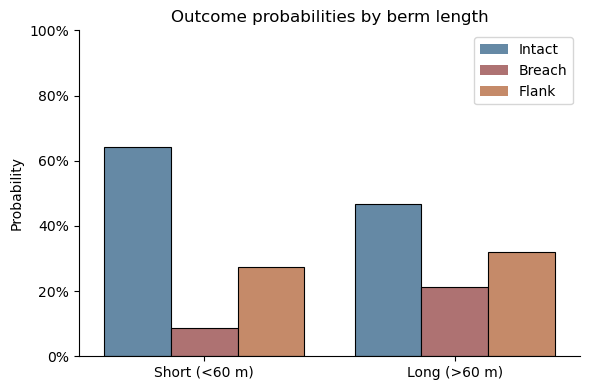

In [49]:
thr = 60

plot_df = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()
plot_df = plot_df.query("Shape_Leng != @thr").copy()  # optional: drop exactly-60

short_lbl = f"Short (<{thr} m)"
long_lbl  = f"Long (>{thr} m)"

plot_df["len_bin"] = pd.Categorical(
    np.where(plot_df["Shape_Leng"] > thr, long_lbl, short_lbl),
    categories=[short_lbl, long_lbl], ordered=True
)
plot_df["failed"] = plot_df["Fail_Type"].ne("Intact")

# ---- probabilities (tidy) ----
p_outcome = pd.crosstab(plot_df["len_bin"], plot_df["Fail_Type"], normalize="index")
out_long = p_outcome.reset_index().melt(id_vars="len_bin", var_name="Fail_Type", value_name="prob")

# ---- palettes (consistent with canonical colours defined above) ----
palette_outcome = {"Intact": INTACT_COL, "Breach": BREACH_COL, "Flank": FLANK_COL}

# stable hue order
base_order = ["Intact", "Breach", "Flank"]
fail_order = [c for c in base_order if c in out_long["Fail_Type"].unique()] + \
             [c for c in out_long["Fail_Type"].unique() if c not in base_order]

def add_bar_edges(ax, lw=0.8):
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(lw)

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=out_long,
    x="len_bin", y="prob", hue="Fail_Type",
    hue_order=fail_order, palette=palette_outcome,
    errorbar=None, ax=ax
)
add_bar_edges(ax)
ax.set_title("Outcome probabilities by berm length")
ax.set_xlabel("")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)

try:
    sns.move_legend(ax, "upper right", title="", frameon=True)
except Exception:
    pass

sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()


In [22]:
from registry import _upsert_registry_block, _update_txt_registries


In [23]:
from registry import _upsert_registry_block, _update_txt_registries


Updated → ../latex/figure_report_paper2.tex  (Figure 2)
Updated: ../figures/paper2/figure_registry.txt
Updated: ../figures/paper2/figure_registry_concise.txt


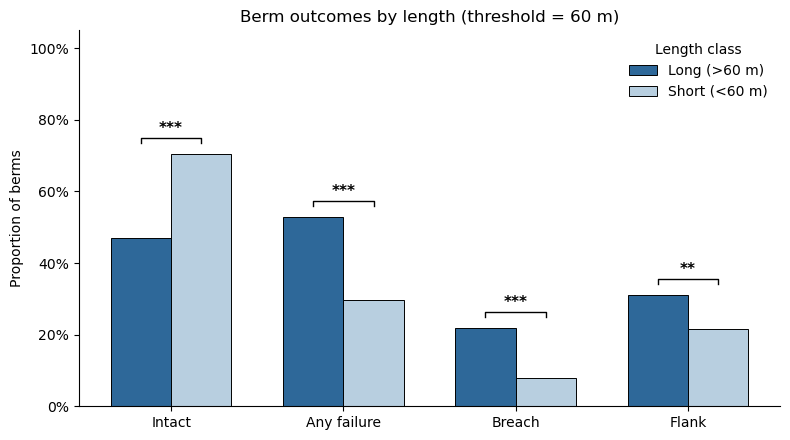

In [24]:
# Visualise Long vs Short proportions with significance annotations
plot_metrics = ["Intact", "Any failure", "Breach", "Flank"]

plot_df = (
    len_metrics.loc[plot_metrics, [long_lbl, short_lbl, "sig"]]
    .reset_index()
    .rename(columns={"index": "Metric"})
    .melt(id_vars=["Metric", "sig"], var_name="Length", value_name="Proportion")
)

fig, ax = plt.subplots(figsize=(8, 4.5))

bar_colors = {long_lbl: LENGTH_COLORS["Long (> 50 m)"], short_lbl: LENGTH_COLORS["Short (≤ 50 m)"]}
x = np.arange(len(plot_metrics))
width = 0.35

for i, (lbl, offset) in enumerate([(long_lbl, -width/2), (short_lbl, width/2)]):
    vals = [len_metrics.loc[m, lbl] for m in plot_metrics]
    bars = ax.bar(x + offset, vals, width, label=lbl,
                  color=bar_colors[lbl], edgecolor="black", linewidth=0.7)

# Significance brackets above each pair
for i, metric in enumerate(plot_metrics):
    sig = len_metrics.loc[metric, "sig"]
    p_l = len_metrics.loc[metric, long_lbl]
    p_s = len_metrics.loc[metric, short_lbl]
    top = max(p_l, p_s) + 0.03
    bracket_h = 0.015
    ax.plot([x[i] - width/2, x[i] - width/2, x[i] + width/2, x[i] + width/2],
            [top, top + bracket_h, top + bracket_h, top],
            lw=1, color="black")
    color = "black" if sig != "ns" else "#888888"
    ax.text(x[i], top + bracket_h + 0.005, sig, ha="center", va="bottom",
            fontsize=11, color=color, fontweight="bold" if sig != "ns" else "normal")

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics)
ax.set_ylabel("Proportion of berms")
ax.set_title(f"Berm outcomes by length (threshold = {thr} m)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(title="Length class", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()

from pathlib import Path
out_path = Path("../figures/paper2/fig2.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")

register_paper2_figure(
    label="fig2",
    file_name=out_path.name,
    stats_text="Grouped comparison of berm outcome proportions between Long and Short berm classes, with per-metric 2×2 contingency-table significance tests shown as bracket annotations.",
    interpretation_text="Outcome proportions differ by length class, and this figure serves as Paper 2 Figure 2 for the breach/flank-focused comparison.",
)

plt.show()

,B horizon,No B horizon,Δ,direction,p-value (1-sided),sig
Intact,54.7,61.7,-0.071,B < No-B,0.0318,*
Any failure,45.3,38.3,0.071,B > No-B,0.0318,*
Breach,11.8,16.5,-0.047,B < No-B,0.0452,*
Flank,33.6,21.8,0.118,B > No-B,0.000245,***
Vegetation response,55.4,42.8,0.126,B > No-B,0.000459,***
Breach | failed,26.0,43.0,-0.171,B < No-B,0.00125,**
Flank | failed,74.0,57.0,0.171,B > No-B,0.00125,**


Saved → ../figures/paper2/fig_bhorizon_outcomes.png


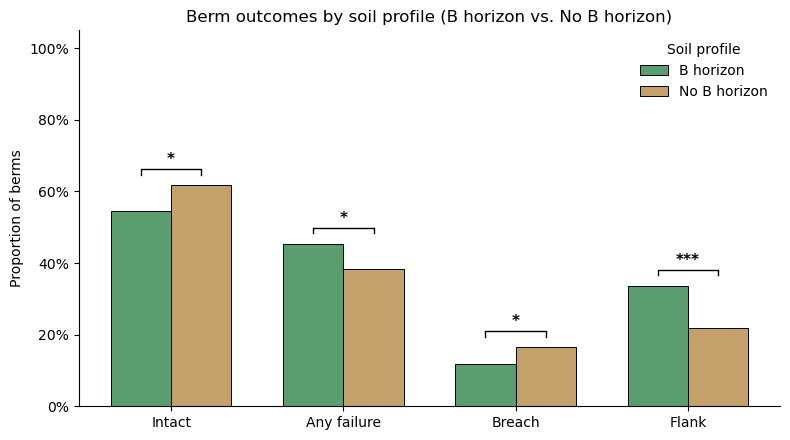

In [25]:

# ── Outcomes by B horizon (Soil_Development) ──────────────────────────────────
from constants import SOILDEV_COLORS  # reload to pick up any updated colours

b_lbl    = "B horizon"
no_b_lbl = "No B horizon"

df_sd = data.dropna(subset=["Soil_Development"]).copy()
df_sd = df_sd[df_sd["Soil_Development"].isin([b_lbl, no_b_lbl])]
df_sd["failed"] = df_sd["Fail_Type"].ne("Intact")

n_b    = (df_sd["Soil_Development"] == b_lbl).sum()
n_no_b = (df_sd["Soil_Development"] == no_b_lbl).sum()

# ── Metric table (same structure as len_metrics) ─────────────────────────────
sd_rows = {}
for metric, pos_mask_fn in [
    ("Intact",       lambda d: d["Fail_Type"] == "Intact"),
    ("Any failure",  lambda d: d["failed"]),
    ("Breach",       lambda d: d["Fail_Type"] == "Breach"),
    ("Flank",        lambda d: d["Fail_Type"] == "Flank"),
    (LBL_EFFECTIVE,  lambda d: d["Effective"] == LBL_EFFECTIVE),
]:
    mask = pos_mask_fn(df_sd)
    c_b    = mask[df_sd["Soil_Development"] == b_lbl].sum()
    c_no_b = mask[df_sd["Soil_Development"] == no_b_lbl].sum()
    p_val, _ = _fisher_one_sided(c_b, n_b, c_no_b, n_no_b)
    p_b, p_no_b = c_b / n_b, c_no_b / n_no_b
    sd_rows[metric] = {
        b_lbl: p_b, no_b_lbl: p_no_b,
        "Δ": round(p_b - p_no_b, 3),
        "direction": f"B {'>' if p_b >= p_no_b else '<'} No-B",
        "p-value (1-sided)": p_val,
        "sig": _sig_stars(p_val),
    }

# Conditional (among failed only)
df_f2 = df_sd[df_sd["failed"]]
n_bf  = (df_f2["Soil_Development"] == b_lbl).sum()
n_no_bf = (df_f2["Soil_Development"] == no_b_lbl).sum()
for metric, ft in [("Breach | failed", "Breach"), ("Flank | failed", "Flank")]:
    c_b    = ((df_f2["Fail_Type"] == ft) & (df_f2["Soil_Development"] == b_lbl)).sum()
    c_no_b = ((df_f2["Fail_Type"] == ft) & (df_f2["Soil_Development"] == no_b_lbl)).sum()
    p_val, _ = _fisher_one_sided(c_b, n_bf, c_no_b, n_no_bf)
    p_b, p_no_b = c_b / n_bf, c_no_b / n_no_bf
    sd_rows[metric] = {
        b_lbl: p_b, no_b_lbl: p_no_b,
        "Δ": round(p_b - p_no_b, 3),
        "direction": f"B {'>' if p_b >= p_no_b else '<'} No-B",
        "p-value (1-sided)": p_val,
        "sig": _sig_stars(p_val),
    }

sd_metrics = pd.DataFrame(sd_rows).T
sd_metrics[[b_lbl, no_b_lbl]] = sd_metrics[[b_lbl, no_b_lbl]].astype(float)

display(sd_metrics.assign(
    **{b_lbl:  (sd_metrics[b_lbl]  * 100).round(1),
       no_b_lbl: (sd_metrics[no_b_lbl] * 100).round(1),
       "Δ":    sd_metrics["Δ"].astype(float).round(3),
       "p-value (1-sided)": sd_metrics["p-value (1-sided)"].apply(lambda x: f"{x:.3g}")}
)[[b_lbl, no_b_lbl, "Δ", "direction", "p-value (1-sided)", "sig"]])

# ── Plot ───────────────────────────────────────────────────────────────────────
plot_metrics_sd = ["Intact", "Any failure", "Breach", "Flank"]

fig, ax = plt.subplots(figsize=(8, 4.5))

bar_colors_sd = {
    b_lbl:    SOILDEV_COLORS.get(b_lbl,    "#5a9e6f"),
    no_b_lbl: SOILDEV_COLORS.get(no_b_lbl, "#c4a06b"),
}
x = np.arange(len(plot_metrics_sd))
width = 0.35

for lbl, offset in [(b_lbl, -width / 2), (no_b_lbl, width / 2)]:
    vals = [sd_metrics.loc[m, lbl] for m in plot_metrics_sd]
    ax.bar(x + offset, vals, width, label=lbl,
           color=bar_colors_sd[lbl], edgecolor="black", linewidth=0.7)

# Significance brackets
for i, metric in enumerate(plot_metrics_sd):
    sig = sd_metrics.loc[metric, "sig"]
    p_b_val    = sd_metrics.loc[metric, b_lbl]
    p_no_b_val = sd_metrics.loc[metric, no_b_lbl]
    top = max(p_b_val, p_no_b_val) + 0.03
    bracket_h = 0.015
    ax.plot([x[i] - width / 2, x[i] - width / 2, x[i] + width / 2, x[i] + width / 2],
            [top, top + bracket_h, top + bracket_h, top],
            lw=1, color="black")
    color = "black" if sig != "ns" else "#888888"
    ax.text(x[i], top + bracket_h + 0.005, sig, ha="center", va="bottom",
            fontsize=11, color=color,
            fontweight="bold" if sig != "ns" else "normal")

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics_sd)
ax.set_ylabel("Proportion of berms")
ax.set_title("Berm outcomes by soil profile (B horizon vs. No B horizon)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(title="Soil profile", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()

from pathlib import Path
out_path = Path("../figures/paper2/fig_bhorizon_outcomes.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()


Saved → ../figures/paper2/fig_texture_fail_type.png


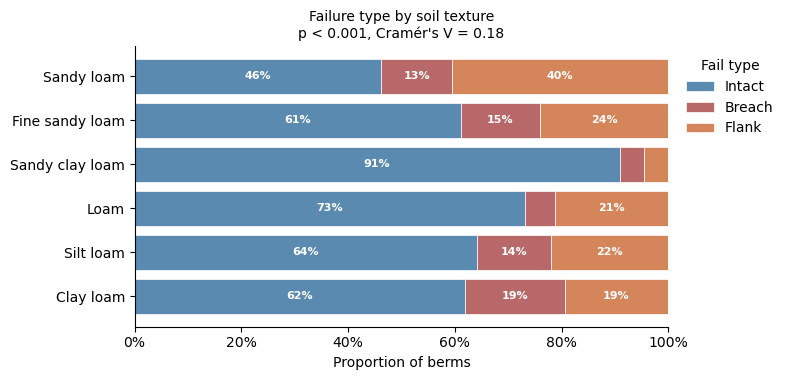

In [ ]:

# ── Outcomes by soil texture: Fine vs. Coarse ─────────────────────────────────
from constants import TEXTURE_COLORS
from registry import register_paper2_figure

# Fine = clay/silt-bearing; Coarse = sandy-dominated
_fine_textures   = ["Clay loam", "Silt loam", "Loam", "Sandy clay loam"]
_coarse_textures = ["Fine sandy loam", "Sandy loam", "Loamy sand", "Loamy coarse sand"]
fine_lbl   = "Fine"
coarse_lbl = "Coarse"

# Pick canonical colours from the finest and coarsest ends of TEXTURE_COLORS
_fine_col   = TEXTURE_COLORS["Clay loam"]          # "#7b5e3a" rich brown
_coarse_col = TEXTURE_COLORS["Sandy loam"]          # "#e8d4a8" pale sand

def _tex_class(t):
    if t in _fine_textures:   return fine_lbl
    if t in _coarse_textures: return coarse_lbl
    return np.nan

df_tex = data.dropna(subset=["Texture", "Fail_Type"]).copy()
df_tex["TexClass"] = df_tex["Texture"].map(_tex_class)
df_tex = df_tex.dropna(subset=["TexClass"])
df_tex["failed"] = df_tex["Fail_Type"].ne("Intact")

n_fine   = (df_tex["TexClass"] == fine_lbl).sum()
n_coarse = (df_tex["TexClass"] == coarse_lbl).sum()
print(f"Fine n={n_fine}, Coarse n={n_coarse}")

# ── Metric table ──────────────────────────────────────────────────────────────
tex_rows = {}
for metric, pos_mask_fn in [
    ("Intact",       lambda d: d["Fail_Type"] == "Intact"),
    ("Any failure",  lambda d: d["failed"]),
    ("Breach",       lambda d: d["Fail_Type"] == "Breach"),
    ("Flank",        lambda d: d["Fail_Type"] == "Flank"),
    (LBL_EFFECTIVE,  lambda d: d["Effective"] == LBL_EFFECTIVE),
]:
    mask = pos_mask_fn(df_tex)
    c_f = mask[df_tex["TexClass"] == fine_lbl].sum()
    c_c = mask[df_tex["TexClass"] == coarse_lbl].sum()
    p_val, _ = _fisher_one_sided(c_f, n_fine, c_c, n_coarse)
    p_f, p_c = c_f / n_fine, c_c / n_coarse
    tex_rows[metric] = {
        fine_lbl: p_f, coarse_lbl: p_c,
        "Δ": round(p_f - p_c, 3),
        "direction": f"Fine {'>' if p_f >= p_c else '<'} Coarse",
        "p-value (1-sided)": p_val,
        "sig": _sig_stars(p_val),
    }

# Conditional (among failed only)
df_f3   = df_tex[df_tex["failed"]]
n_ff    = (df_f3["TexClass"] == fine_lbl).sum()
n_cf    = (df_f3["TexClass"] == coarse_lbl).sum()
for metric, ft in [("Breach | failed", "Breach"), ("Flank | failed", "Flank")]:
    c_f = ((df_f3["Fail_Type"] == ft) & (df_f3["TexClass"] == fine_lbl)).sum()
    c_c = ((df_f3["Fail_Type"] == ft) & (df_f3["TexClass"] == coarse_lbl)).sum()
    p_val, _ = _fisher_one_sided(c_f, n_ff, c_c, n_cf)
    p_f, p_c = c_f / n_ff, c_c / n_cf
    tex_rows[metric] = {
        fine_lbl: p_f, coarse_lbl: p_c,
        "Δ": round(p_f - p_c, 3),
        "direction": f"Fine {'>' if p_f >= p_c else '<'} Coarse",
        "p-value (1-sided)": p_val,
        "sig": _sig_stars(p_val),
    }

tex_metrics = pd.DataFrame(tex_rows).T
tex_metrics[[fine_lbl, coarse_lbl]] = tex_metrics[[fine_lbl, coarse_lbl]].astype(float)

display(tex_metrics.assign(
    **{fine_lbl:   (tex_metrics[fine_lbl]   * 100).round(1),
       coarse_lbl: (tex_metrics[coarse_lbl] * 100).round(1),
       "Δ":    tex_metrics["Δ"].astype(float).round(3),
       "p-value (1-sided)": tex_metrics["p-value (1-sided)"].apply(lambda x: f"{x:.3g}")}
)[[fine_lbl, coarse_lbl, "Δ", "direction", "p-value (1-sided)", "sig"]])

# ── Plot ───────────────────────────────────────────────────────────────────────
_plot_metrics = ["Intact", "Any failure", "Breach", "Flank"]
_bar_colors   = {fine_lbl: _fine_col, coarse_lbl: _coarse_col}

fig, ax = plt.subplots(figsize=(8, 4.5))
x     = np.arange(len(_plot_metrics))
_w    = 0.35

for lbl, offset in [(fine_lbl, -_w / 2), (coarse_lbl, _w / 2)]:
    vals = [tex_metrics.loc[m, lbl] for m in _plot_metrics]
    ax.bar(x + offset, vals, _w, label=f"{lbl} (n={n_fine if lbl == fine_lbl else n_coarse})",
           color=_bar_colors[lbl], edgecolor="black", linewidth=0.7)

# Significance brackets
for i, metric in enumerate(_plot_metrics):
    sig  = tex_metrics.loc[metric, "sig"]
    top  = max(tex_metrics.loc[metric, fine_lbl], tex_metrics.loc[metric, coarse_lbl]) + 0.03
    bh   = 0.015
    ax.plot([x[i] - _w / 2, x[i] - _w / 2, x[i] + _w / 2, x[i] + _w / 2],
            [top, top + bh, top + bh, top], lw=1, color="black")
    ax.text(x[i], top + bh + 0.005, sig, ha="center", va="bottom",
            fontsize=11, color="black" if sig != "ns" else "#888888",
            fontweight="bold" if sig != "ns" else "normal")

ax.set_xticks(x)
ax.set_xticklabels(_plot_metrics)
ax.set_ylabel("Proportion of berms")
ax.set_title("Berm outcomes by soil texture (Fine vs. Coarse)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(title="Texture class", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()

from pathlib import Path
_out = Path("../figures/paper2/fig3_texture_fine_coarse.png")
_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out, dpi=300, bbox_inches="tight")

register_paper2_figure(
    "fig3", "fig3_texture_fine_coarse.png",
    description=(
        f"Berm outcomes by soil texture class (Fine n={n_fine}, Coarse n={n_coarse}). "
        f"Fine textures include: {', '.join(_fine_textures)}. "
        f"Coarse textures include: {', '.join(_coarse_textures)}. "
        f"Grouped bar chart showing Intact, Any failure, Breach, and Flank proportions "
        f"with one-sided Fisher exact p-values."
    ),
    concise=(
        f"Berm outcomes for fine (n={n_fine}) vs. coarse (n={n_coarse}) soil textures. "
        "Compares Intact, Any failure, Breach, and Flank rates with one-sided Fisher exact tests."
    ),
)
print(f"Saved → {_out}")
plt.show()


In [26]:
def length_outcome_probs(df, threshold=60, length_col="Shape_Leng",
                         fail_col="Fail_Type", intact_val="Intact"):
    """
    Print conditional outcome probabilities for berms above/below a length threshold.
    Returns a DataFrame with the same data for export.

    Parameters
    ----------
    df          : DataFrame containing berm records
    threshold   : length split (metres); berms == threshold are excluded
    length_col  : column with berm length
    fail_col    : column with failure type (must include intact_val for intact berms)
    intact_val  : label used for intact berms in fail_col
    """
    d = df.query(f"{length_col} != @threshold").copy()
    long  = d[d[length_col] > threshold]
    short = d[d[length_col] < threshold]

    def _p(subset, condition):
        n = len(subset)
        k = condition(subset).sum()
        return k / n if n > 0 else float("nan"), k, n

    outcomes = {
        "Any failure":       lambda s: s[fail_col] != intact_val,
        "Breach":            lambda s: s[fail_col] == "Breach",
        "Flank":             lambda s: s[fail_col] == "Flank",
        "Intact":            lambda s: s[fail_col] == intact_val,
    }
    cond_outcomes = {
        "Breach | failed":   lambda s: s[fail_col] == "Breach",
        "Flank  | failed":   lambda s: s[fail_col] == "Flank",
    }

    header = f"{'Metric':<22}  {'Long (>{t}m)':>14}  {'Short (<{t}m)':>14}  {'Δ':>8}".format(t=threshold)
    print(header)
    print("-" * len(header))

    rows = []

    for label, fn in outcomes.items():
        p_l, k_l, n_l = _p(long,  fn)
        p_s, k_s, n_s = _p(short, fn)
        delta = p_l - p_s
        print(f"  {label:<20}  {p_l:>6.1%} ({k_l}/{n_l})  {p_s:>6.1%} ({k_s}/{n_s})  {delta:>+7.1f} pp")
        rows.append({
            "Metric": label,
            "Among": "All",
            f"Long (>{threshold} m) k/n": f"{k_l}/{n_l}",
            f"Long (>{threshold} m) %": f"{p_l:.1%}",
            f"Short (<{threshold} m) k/n": f"{k_s}/{n_s}",
            f"Short (<{threshold} m) %": f"{p_s:.1%}",
            "Δ": f"{delta:+.3f}",
        })

    print()
    failed_long  = long[long[fail_col]  != intact_val]
    failed_short = short[short[fail_col] != intact_val]
    print(f"  {'[Among failed only]':<20}")
    for label, fn in cond_outcomes.items():
        p_l, k_l, n_l = _p(failed_long,  fn)
        p_s, k_s, n_s = _p(failed_short, fn)
        delta = p_l - p_s
        print(f"  {label:<20}  {p_l:>6.1%} ({k_l}/{n_l})  {p_s:>6.1%} ({k_s}/{n_s})  {delta:>+7.1f} pp")
        rows.append({
            "Metric": label,
            "Among": "Failed only",
            f"Long (>{threshold} m) k/n": f"{k_l}/{n_l}",
            f"Long (>{threshold} m) %": f"{p_l:.1%}",
            f"Short (<{threshold} m) k/n": f"{k_s}/{n_s}",
            f"Short (<{threshold} m) %": f"{p_s:.1%}",
            "Δ": f"{delta:+.3f}",
        })

    return pd.DataFrame(rows)

length_df = length_outcome_probs(data, threshold=60)


Metric                    Long (>60m)   Short (<60m)         Δ
--------------------------------------------------------------
  Any failure            52.9% (199/376)   29.6% (118/399)     +0.2 pp
  Breach                 21.8% (82/376)    8.0% (32/399)     +0.1 pp
  Flank                  31.1% (117/376)   21.6% (86/399)     +0.1 pp
  Intact                 47.1% (177/376)   70.4% (281/399)     -0.2 pp

  [Among failed only] 
  Breach | failed        41.2% (82/199)   27.1% (32/118)     +0.1 pp
  Flank  | failed        58.8% (117/199)   72.9% (86/118)     -0.1 pp


In [27]:
# ── Export len_metrics as Paper 2 SI Table 2 (LaTeX) ───────────────────────────────────────────
from pathlib import Path
from datetime import datetime
import re

def _upsert_si_table(latex_path, tag, table_latex):
    """Replace content between %% {tag}_START and %% {tag}_END markers."""
    latex_path = Path(latex_path)
    if not latex_path.exists():
        print(f"⚠ {latex_path} not found — skipping SI table upsert")
        return
    text = latex_path.read_text(encoding="utf-8")
    start_tag = f"%% {tag}_START"
    end_tag   = f"%% {tag}_END"
    patt = rf"({re.escape(start_tag)})\n(.*?)({re.escape(end_tag)})"
    def _repl(m):
        return f"{m.group(1)}\n{table_latex}\n{m.group(3)}"
    if re.search(patt, text, flags=re.S):
        text = re.sub(patt, _repl, text, flags=re.S)
    else:
        # Insert just before \end{document} if markers missing
        text = text.replace(r"\end{document}",
                            f"{start_tag}\n{table_latex}\n{end_tag}\n\n\\end{{document}}")
    latex_path.write_text(text, encoding="utf-8")


# ── Format len_metrics for LaTeX ─────────────────────────────────────────────────────
si_tab = len_metrics.copy()

# Round numeric columns to 3 decimal places
num_cols = si_tab.select_dtypes(include="number").columns
si_tab[num_cols] = si_tab[num_cols].round(3)


# ── Save CSV to figures/paper2/ ──────────────────────────────────────────
_csv_dir = Path("../figures/paper2")
_csv_dir.mkdir(parents=True, exist_ok=True)
_csv_path = _csv_dir / "SI_table2_length_outcomes.csv"
# columns at this point are still the original (pre-LaTeX-rename) names
si_tab.rename(columns={"Δ": "Delta", "sig": "Sig"}).to_csv(_csv_path)
print(f"CSV saved  → {_csv_path}")


# Rename columns for presentation
col_rename = {
    long_lbl:           f"P(Long $>$ {thr}\\,m)",
    short_lbl:          f"P(Short $\\leq$ {thr}\\,m)",
    "Δ":               "$\\Delta$",
    "direction":        "Direction",
    "p-value (1-sided)":"$p$ (1-sided)",
    "sig":              "Sig.",
}
si_tab = si_tab.rename(columns=col_rename)

# Column order: P(long), P(short), Δ, Direction, p, Sig.
col_order = [
    f"P(Long $>$ {thr}\\,m)",
    f"P(Short $\\leq$ {thr}\\,m)",
    "$\\Delta$",
    "Direction",
    "$p$ (1-sided)",
    "Sig.",
]
col_order = [c for c in col_order if c in si_tab.columns]
si_tab = si_tab[col_order]

# Build LaTeX tabular string
# l for Outcome index + numeric/text cols
col_spec = "l" + "".join(
    "l" if c in ("Direction", "Sig.") else "r"
    for c in si_tab.columns
)
updated = datetime.now().strftime("%Y-%m-%d %H:%M")

lines = [
    r"\begin{table}[H]",
    r"  \centering",
    rf"  \caption{{SI Table 2: Berm outcome proportions by length class (threshold = {thr}\,m). "
        r"$\Delta$ = P(Long) $-$ P(Short) as a decimal proportion. "
        r"$p$-values from one-sided Fisher exact tests in direction of the observed difference. "
        rf"Updated {updated}.}}",
    r"  \label{tab:si_table2_length_outcomes}",
    r"  \small",
    rf"  \begin{{tabular}}{{{col_spec}}}",
    r"    \toprule",
    "    Outcome & " + " & ".join(str(c) for c in si_tab.columns) + r" \\",
    r"    \midrule",
]
for idx, row in si_tab.iterrows():
    vals = " & ".join(
        f"{v:.3f}" if isinstance(v, float) else str(v)
        for v in row
    )
    lines.append(f"    {idx} & {vals}" + r" \\")
lines += [
    r"    \bottomrule",
    r"  \end{tabular}",
    r"\end{table}",
]

table_latex = "\n".join(lines)

# Write to the Paper 2 LaTeX report
latex_path = Path("../latex/figure_report_paper2.tex")
_upsert_si_table(latex_path, "SI_TABLE_2", table_latex)
print(f"SI Table 2 written to {latex_path}")
print()
display(si_tab)


CSV saved  → ../figures/paper2/SI_table2_length_outcomes.csv
SI Table 2 written to ../latex/figure_report_paper2.tex



,"P(Long $>$ 60\,m)","P(Short $\leq$ 60\,m)",$\Delta$,Direction,$p$ (1-sided),Sig.
Intact,0.471,0.704,-0.234,Long < Short,0.0,***
Any failure,0.529,0.296,0.234,Long > Short,0.0,***
Breach,0.218,0.080,0.138,Long > Short,0.0,***
Flank,0.311,0.216,0.096,Long > Short,0.001606,**
Vegetation response,0.487,0.464,0.023,Long > Short,0.284326,ns
Breach | failed,0.412,0.271,0.141,Long > Short,0.007655,**
Flank | failed,0.588,0.729,-0.141,Long < Short,0.007655,**
